In [33]:
import pandas as pd
import numpy as np
import joblib
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler
import os
from typing import Dict, List
import pickle
from sklearn.metrics import accuracy_score


In [2]:
cluster_reverse_mapping =joblib.load('../models/fuzzy_cmeans_model.pkl')['cluster_names']
cluster_mapping = {v: k for k, v in cluster_reverse_mapping.items()}

In [3]:
# predicts the cluster for a dataframe
def predict_clusters(df_all_features,features_path = '../data/features_with_weights.csv', model_file='../models/fuzzy_cmeans_model.pkl'):
    features_df = pd.read_csv(features_path)
    feature_columns = features_df['Feature'].to_list()
    weights = features_df['FinalWeight'].to_list()
    
    df = df_all_features[feature_columns]
    standardScaler = StandardScaler()
    normalizedFeatures = standardScaler.fit_transform(df)

    weightedFeatures = normalizedFeatures * weights

    # Load the saved model
    fuzzy_cmeans_model = joblib.load(model_file)
    centers = fuzzy_cmeans_model['centers']
    mapping = fuzzy_cmeans_model['mapping']
    cluster_names = fuzzy_cmeans_model['cluster_names']
    u_pred, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            weightedFeatures.T, centers, fuzzy_cmeans_model['fuzziness_parameter'], 
            error=0.005, maxiter=1000
        )
    # Get hard cluster assignments
    hard_labels_pred = np.argmax(u_pred, axis=0)

    # Apply the saved mapping
    renumbered_labels_pred = mapping[hard_labels_pred]

    # Convert to cluster names
    named_labels_pred = np.vectorize(cluster_names.get)(renumbered_labels_pred)
    # memebership_degree = u_pred
    return pd.Series(named_labels_pred)
    


In [4]:
def add_cluster_prediction(df_all_features,features_path = '../data/features_with_weights.csv', model_file='../models/fuzzy_cmeans_model.pkl'):
    cluster_predictions = predict_clusters(df_all_features,features_path, model_file)
    df_all_features['cluster_prediction'] = cluster_predictions
    return df_all_features

In [5]:
file = "../data/cleaned/monthlymetrics/customer_metrics_2022_01_data.csv"
data = pd.read_csv(file)
unique_customers = data["CustomerName"].unique()

In [8]:
def load_monthly_data(input_dir: str = "../data/cleaned/monthlymetrics") -> pd.DataFrame:
    """Load and preprocess all monthly CSV files into a single DataFrame."""
    all_data = []
    columns = None
    
    for file in sorted(os.listdir(input_dir)):
        if file.endswith(".csv"):
            file_path = os.path.join(input_dir, file)
            df = pd.read_csv(file_path)
            
            # Set columns from the first file, excluding Year and Month if not present
            if columns is None:
                columns = df.columns.tolist()
                if 'Year' not in columns:
                    columns.extend(['Year', 'Month'])
            
            # Add Year and Month from filename
            df["Year"] = file[17:21]
            df["Month"] = file[22:24]
            
            # Ensure consistent columns
            all_data.append(df[columns])
    
    return pd.concat(all_data, ignore_index=True)

def get_customer_time_series(
    customer_names: List[str],
    input_dir: str = "../data/cleaned/monthlymetrics"
) -> Dict[str, pd.DataFrame]:
    """Generate time series DataFrames for specified customers."""
    # Load all data once
    full_data = load_monthly_data(input_dir)
    
    # Create dictionary of customer-specific DataFrames
    customers_dataframes = {
        customer: full_data[full_data['CustomerName'] == customer].copy()
        for customer in customer_names
    }
    
    return customers_dataframes

In [9]:
customers_dataframes = get_customer_time_series(unique_customers)

In [12]:
def update_customer_time_series(
    customer_df: pd.DataFrame,
    customer_name: str,
    test_dir: str = "../data/cleaned/monthlymetrics/test"
) -> pd.DataFrame:
    """Update a customer's time series DataFrame with the next 24 months of test data."""
    # Load test data
    test_data = []
    columns = customer_df.columns.tolist()  # Use columns from input DataFrame
    
    for file in sorted(os.listdir(test_dir)):
        if file.endswith(".csv"):
            file_path = os.path.join(test_dir, file)
            df = pd.read_csv(file_path)
            
            # Add Year and Month from filename
            df["Year"] = file[17:21]
            df["Month"] = file[22:24]
            
            # Filter for the specific customer
            customer_test_data = df[df['CustomerName'] == customer_name]
            
            # Ensure consistent columns
            if not customer_test_data.empty:
                test_data.append(customer_test_data[columns])
    
    # Combine test data
    if test_data:
        test_df = pd.concat(test_data, ignore_index=True)
        # Append test data to the original DataFrame
        updated_df = pd.concat([customer_df, test_df], ignore_index=True)
    else:
        updated_df = customer_df.copy()  # Return original if no test data found
    
    # Sort by Year and Month to ensure chronological order
    updated_df = updated_df.sort_values(by=['Year', 'Month']).reset_index(drop=True)
    
    return updated_df

In [13]:
for customer, df in customers_dataframes.items():
    customers_dataframes[customer] = update_customer_time_series(df, customer)

In [18]:
with open('../data/cleaned/all_customer_data_time_series.pkl', 'wb') as f:
    pickle.dump(customers_dataframes, f)

In [19]:
combined_df = pd.DataFrame()
for customer, df in customers_dataframes.items():
    # Add the customer name to the dataframe
    df['CustomerName'] = customer
    # Append the dataframe to the combined dataframe
    combined_df = pd.concat([combined_df, df], ignore_index=True)

In [20]:
add_cluster_prediction(combined_df)

,CustomerName,TotalRevenue,TotalProfit,TotalUnitPrice,TotalSalesQty,OrderCount,NumDistinctProducts,NumDistinctProductGroups,BranchCount,TopProductID,...,CustomerLifetimeDays,AvgOrderValue,RepeatPurchaseRatio,HighProfitProductShare,PopularProductShare,HighProfitOrderRatio,PopularOrderRatio,Year,Month,cluster_prediction
0,ADAMS PLC AND SONS,8645.13,3680.91,343.211359,22052.0,12.0,29.0,10.0,1.0,PGO-856-PV3,...,27.0,720.427500,0.413793,0.157895,0.263158,6.0,10.0,2022,01,Bronze
1,ADAMS PLC AND SONS,6956.58,2660.24,353.780509,16696.0,10.0,38.0,10.0,1.0,OZW-556-BS7,...,19.0,695.658000,0.263158,0.080000,0.160000,4.0,8.0,2022,02,Bronze
2,ADAMS PLC AND SONS,22112.17,9981.44,3051.630219,63151.0,12.0,66.0,17.0,2.0,KOH-232-IO4,...,28.0,1842.680833,0.181818,0.154639,0.237113,15.0,23.0,2022,03,Bronze
3,ADAMS PLC AND SONS,15012.09,6389.46,1120.715073,33151.0,13.0,53.0,13.0,2.0,CCX-754-QX9,...,22.0,1154.776154,0.245283,0.164384,0.150685,12.0,11.0,2022,04,Bronze
4,ADAMS PLC AND SONS,5217.06,2278.15,124.382690,10204.0,10.0,14.0,8.0,2.0,JJQ-303-OR6,...,16.0,521.706000,0.714286,0.227273,0.181818,5.0,4.0,2022,05,Bronze
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37399,ZIMMERMAN-WISE PLC,1743.97,906.97,116.264667,15.0,1.0,1.0,1.0,1.0,RAT-827-KI8,...,0.0,1743.970000,1.000000,1.000000,0.000000,1.0,0.0,2024,08,Rock
37400,ZIMMERMAN-WISE PLC,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2024,09,Rock
37401,ZIMMERMAN-WISE PLC,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2024,10,Rock
37402,ZIMMERMAN-WISE PLC,43.64,22.70,2.909333,15.0,1.0,1.0,1.0,1.0,RFI-183-VJ6,...,0.0,43.640000,1.000000,0.000000,0.000000,0.0,0.0,2024,11,Rock


In [21]:
prediction_data = combined_df[['CustomerName', 'cluster_prediction']]

In [22]:
print(prediction_data)

             CustomerName cluster_prediction
0      ADAMS PLC AND SONS             Bronze
1      ADAMS PLC AND SONS             Bronze
2      ADAMS PLC AND SONS             Bronze
3      ADAMS PLC AND SONS             Bronze
4      ADAMS PLC AND SONS             Bronze
...                   ...                ...
37399  ZIMMERMAN-WISE PLC               Rock
37400  ZIMMERMAN-WISE PLC               Rock
37401  ZIMMERMAN-WISE PLC               Rock
37402  ZIMMERMAN-WISE PLC               Rock
37403  ZIMMERMAN-WISE PLC               Rock

[37404 rows x 2 columns]


In [23]:
prediction_model = joblib.load('../models/voting_ensemble_model.pkl')

In [24]:
# Encode cluster_prediction
prediction_data['cluster_encoded'] = prediction_data['cluster_prediction'].map(cluster_mapping)

# Add a month index (grouped by customer)
prediction_data['month'] = prediction_data.groupby('CustomerName').cumcount()

# Pivot to wide format
wide_prediction_df = prediction_data.pivot(index='CustomerName', columns='month', values='cluster_encoded')

# Rename columns
wide_prediction_df.columns = [f'month_{i+1}' for i in wide_prediction_df.columns]
# Reset index
wide_prediction_df = wide_prediction_df.reset_index()

/var/folders/pf/rh7r7nr92zggr4t5dsl35h2m0000gn/T/ipykernel_1309/3259336979.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['cluster_encoded'] = prediction_data['cluster_prediction'].map(cluster_mapping)
/var/folders/pf/rh7r7nr92zggr4t5dsl35h2m0000gn/T/ipykernel_1309/3259336979.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['month'] = prediction_data.groupby('CustomerName').cumcount()


In [26]:
# remove 'CustomerName' column

wide_prediction_df = wide_prediction_df.drop(columns=['CustomerName'])

In [ ]:
predictions = []
actuals = []
months_evaluated = []
for m in range(24, len(wide_prediction_df.columns)):  # Adjust end based on how far your data goes
    input_cols = [f'month_{i}' for i in range(m - 23, m)]  # Last 23 months
    target_col = f'month_{m}'  # The actual value for this month

    X_test = wide_prediction_df[input_cols].copy()
    y_true = wide_prediction_df[target_col].astype(int)

    # Rename input columns to match training set: month_1 to month_23
    rename_map = {f'month_{i}': f'month_{j+1}' for j, i in enumerate(range(m - 23, m))}
    X_test.rename(columns=rename_map, inplace=True)

    y_pred = prediction_model.predict(X_test)

    predictions.extend(y_pred)
    actuals.extend(y_true)
    months_evaluated.extend([m] * len(y_true))

Predictions for month 24: 1039
Predictions for month 25: 1039
Predictions for month 26: 1039
Predictions for month 27: 1039
Predictions for month 28: 1039
Predictions for month 29: 1039
Predictions for month 30: 1039
Predictions for month 31: 1039
Predictions for month 32: 1039
Predictions for month 33: 1039
Predictions for month 34: 1039
Predictions for month 35: 1039


In [42]:
# Wrap results into a DataFrame for evaluation
results_df = pd.DataFrame({
    'month': months_evaluated,
    'actual': actuals,
    'predicted': predictions
})

# Accuracy
overall_accuracy = accuracy_score(results_df['actual'], results_df['predicted'])
print(f"Overall accuracy: {overall_accuracy:.2f}")

Overall accuracy: 0.97


In [43]:
results_df.head()

,month,actual,predicted
0,24,0,0
1,24,0,0
2,24,0,0
3,24,0,0
4,24,0,0


In [48]:
predicted_df = pd.DataFrame(index=wide_prediction_df.index)
actual_df = pd.DataFrame(index=wide_prediction_df.index)


In [49]:
for m in range(24, len(wide_prediction_df.columns)):  # month_24 onward
    input_cols = [f'month_{i}' for i in range(m - 23, m)]  # Last 23 months
    target_col = f'month_{m}'

    X_test = wide_prediction_df[input_cols].copy()
    y_true = wide_prediction_df[target_col].astype(int)

    # Rename input columns to match training set: month_1 to month_23
    rename_map = {f'month_{i}': f'month_{j+1}' for j, i in enumerate(range(m - 23, m))}
    X_test.rename(columns=rename_map, inplace=True)

    y_pred = prediction_model.predict(X_test)

    # Add to new prediction and actual DataFrames
    predicted_df[f'predicted_{target_col}'] = y_pred
    actual_df[target_col] = y_true


<Axes: title={'center': 'Monthly Prediction Accuracy'}, ylabel='Accuracy'>

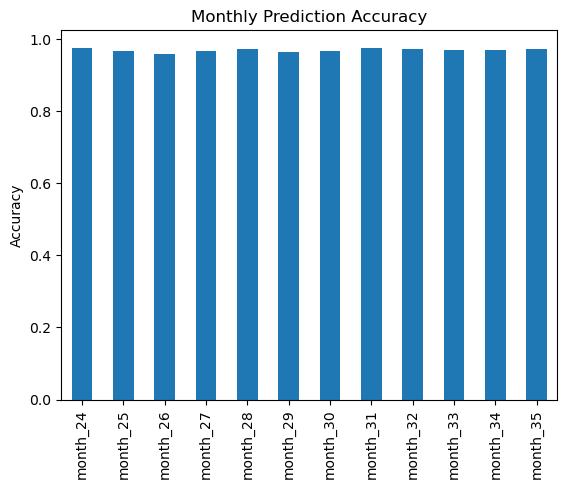

In [54]:
# for comparison
# Strip "predicted_" prefix to match actual_df column names
predicted_df.columns = predicted_df.columns.str.replace("predicted_", "", regex=False)
(predicted_df == actual_df).mean().plot(kind='bar', title='Monthly Prediction Accuracy', ylabel='Accuracy')


In [55]:
# Melt predicted and actual DataFrames
pred_melted = predicted_df.reset_index().melt(id_vars='index', var_name='month', value_name='predicted')
actual_melted = actual_df.reset_index().melt(id_vars='index', var_name='month', value_name='actual')

# Merge them on customer index and month
comparison_df = pd.merge(actual_melted, pred_melted, on=['index', 'month'])


In [56]:
# Count how many times each cluster was predicted and actually occurred per month
actual_counts = comparison_df.groupby(['month', 'actual']).size().unstack(fill_value=0)
pred_counts = comparison_df.groupby(['month', 'predicted']).size().unstack(fill_value=0)


In [57]:
# Difference between actual and predicted counts per cluster per month
diff_counts = pred_counts - actual_counts

# Optional: Normalize difference by actual values to get relative error
relative_error = (pred_counts - actual_counts) / (actual_counts.replace(0, 1))  # avoid division by zero


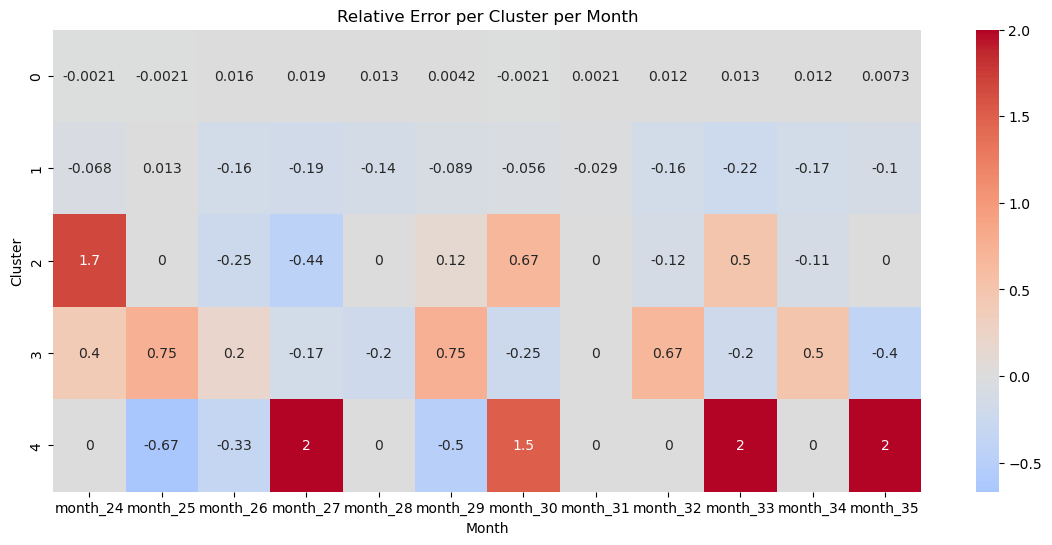

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(relative_error.T, annot=True, cmap='coolwarm', center=0)
plt.title("Relative Error per Cluster per Month")
plt.xlabel("Month")
plt.ylabel("Cluster")
plt.show()
